In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../../src/'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
modify_latex_rc()
modify_latex_rc()
from kea.utils import binning
from kea.simulator import make_field
import numpy as np

In [2]:
oned = make_field((1024,), spectrum_kwargs={'powerlaw': -5./3., 'break_1': 2, 'break_2': 256}, spectrum_function='powerlaw_with_exponentials', normalize_output=True)
twod = make_field((1024,1024), spectrum_kwargs={'powerlaw': -8./3., 'break_1': 2, 'break_2': 256}, spectrum_function='powerlaw_with_exponentials', normalize_output=True)
threed = make_field((512,512,512), spectrum_kwargs={'powerlaw': -11./3., 'break_1': 2, 'break_2': 512}, spectrum_function='powerlaw_with_exponentials', normalize_output=True)

/home/m/Documents/my_libs/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in power
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/m/Documents/my_libs/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in divide
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/m/Documents/my_libs/Kea/src/kea/utils/functions.py:126: RuntimeWarning: invalid value encountered in multiply
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)


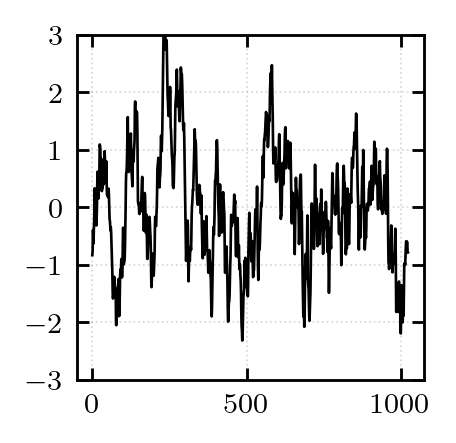

In [39]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=256)
ax.plot(np.arange(len(oned)), oned, linestyle='-', color='black', linewidth=0.75)
ax.set_ylim((-3,3))
pretty_axes(ax)

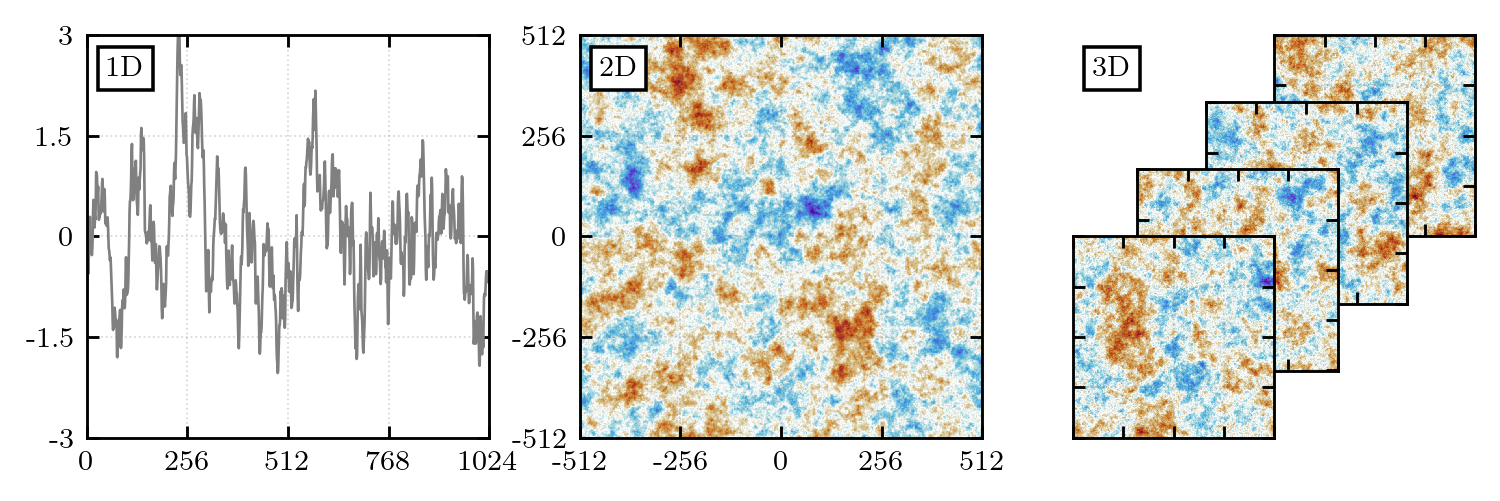

In [54]:
import matplotlib.pyplot as plt
import cmasher as cmr

# fig = plt.figure(figsize=(7., 7./3.), dpi=256)

fig, ax = plt.subplots(1, 3, figsize=(7., 7./3.), dpi=256)

ax1, ax2, ax3 = ax

# ax1 = fig.add_axes([0., 0., 5./8.-0.07, 1.])
ax1.plot(np.arange(len(oned)), ((oned*150.)+(1024//2)), linestyle='-', color='gray', linewidth=0.75)
ax1.imshow(np.ones((1024, 1024)), cmap='Greys', origin='lower')
t, l = make_ax_step(1024)
ax1.set_xticks(t,[0,256,512,512+256,1024])
ax1.set_yticks(t,[-3, -1.5, 0, 1.5, 3])

# ax2 = fig.add_axes([0., 0., 5./8.-0.07, 1.])
ax2.imshow(twod, cmap=cmr.fusion_r, vmin=-5., vmax=5., interpolation='none', origin='lower')

X, Y = 0., 0.
W = 0.5

ax7 = ax3.inset_axes([X+0.5, Y+0.5, W, W])
ax6 = ax3.inset_axes([X+0.33, Y+0.333, W, W])
ax5 = ax3.inset_axes([X+0.16, Y+0.167, W, W])
ax4 = ax3.inset_axes([X, Y, W, W])

ax7.imshow(threed[:,:,0], cmap=cmr.fusion_r, vmin=-5., vmax=5., interpolation='none', origin='lower')
ax6.imshow(threed[:,:,128], cmap=cmr.fusion_r, vmin=-5., vmax=5., interpolation='none', origin='lower')
ax5.imshow(threed[:,:,256], cmap=cmr.fusion_r, vmin=-5., vmax=5., interpolation='none', origin='lower')
ax4.imshow(threed[:,:,(128+256)//2], cmap=cmr.fusion_r, vmin=-5., vmax=5., interpolation='none', origin='lower')

for axx in [ax1, ax2, ax4, ax5, ax6, ax7]:
    pretty_axes(axx)

t, l = make_ax_step(1024)
ax2.set_xticks(t, l)
ax2.set_yticks(t, l)

t, l = make_ax_step(512)

for axx in [ax4, ax5, ax6, ax7]:
    axx.set_xticks(t, l)
    axx.set_yticks(t, l)
    axx.set_xticklabels([])
    axx.set_yticklabels([])
ax3.set_xticks([])
ax3.set_yticks([])
ax3.imshow(np.ones((512, 512)), cmap='Greys')
ax3.set_axis_off()

props = dict(boxstyle='Square', edgecolor='black', linewidth=1., facecolor='white')
ax1.text(0.05, 0.9, '1D', transform=ax1.transAxes, bbox=props)
ax2.text(0.05, 0.9, '2D', transform=ax2.transAxes, bbox=props)
ax3.text(0.05, 0.9, '3D', transform=ax3.transAxes, bbox=props)

fig.subplots_adjust(wspace=0.225)
fig.savefig('example_synthesis.png', bbox_inches='tight', pad_inches=0.1)